In [1]:

# =========================================
# IMPORTS
# =========================================
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import f_oneway

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score
)

from imblearn.over_sampling import RandomOverSampler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader



In [2]:

# =========================================
# DEVICE
# =========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")



Using device: cpu


In [3]:

# =========================================
# LOAD DATASET
# =========================================
folder_path = r"E:\Deep Learning\My_datasets\autism\Eye-tracking Output"

file_list = os.listdir(folder_path)

all_dataframes = []

for file_name in file_list:

    if file_name.endswith('.csv'):

        file_path = os.path.join(folder_path, file_name)

        df = pd.read_csv(file_path)

        all_dataframes.append(df)

combined_df = pd.concat(all_dataframes, ignore_index=True)

print("Combined Shape:", combined_df.shape)



C:\Users\zulqa\AppData\Local\Temp\ipykernel_23624\1501278826.py:16: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
C:\Users\zulqa\AppData\Local\Temp\ipykernel_23624\1501278826.py:16: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
C:\Users\zulqa\AppData\Local\Temp\ipykernel_23624\1501278826.py:16: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
C:\Users\zulqa\AppData\Local\Temp\ipykernel_23624\1501278826.py:16: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
C:\Users\zulqa\AppData\Local\Temp\ipykernel_23624\1501278826.py:16: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
C:\Users\z

Combined Shape: (2252943, 59)


In [4]:

# =========================================
# FEATURES USED IN YOUR NOTEBOOK
# =========================================
columns_of_interest = [
    'Eye Position Right X [mm]',
    'Eye Position Right Y [mm]',
    'Eye Position Right Z [mm]',

    'Eye Position Left X [mm]',
    'Eye Position Left Y [mm]',
    'Eye Position Left Z [mm]',

    'Pupil Position Right X [px]',
    'Pupil Position Right Y [px]',

    'Pupil Position Left X [px]',
    'Pupil Position Left Y [px]',

    'Point of Regard Right X [px]',
    'Point of Regard Right Y [px]',

    'Point of Regard Left X [px]',
    'Point of Regard Left Y [px]'
]


# =========================================
# CLEAN DATA
# =========================================
for column in columns_of_interest:

    combined_df[column] = pd.to_numeric(
        combined_df[column],
        errors='coerce'
    )

    combined_df[column].fillna(
        combined_df[column].mean(),
        inplace=True
    )


# =========================================
# MAP LABELS
# =========================================
def map_category(participant):

    if isinstance(participant, str):

        if participant.startswith('Unidentified'):
            return 'Other'

    if isinstance(participant, int):

        if 1 <= participant <= 29:
            return 'ASD'

        elif 30 <= participant <= 59:
            return 'Neurotypical'

    return 'Other'


combined_df['Participant Group'] = combined_df[
    'Participant'
].apply(map_category)


C:\Users\zulqa\AppData\Local\Temp\ipykernel_23624\921754046.py:37: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_df[column].fillna(


In [5]:


# =========================================
# KEEP ONLY ASD + Neurotypical
# =========================================
asd_td_df = combined_df[
    (combined_df['Participant Group'] == 'ASD') |
    (combined_df['Participant Group'] == 'Neurotypical')
]

print(asd_td_df['Participant Group'].value_counts())



Participant Group
Neurotypical    225675
ASD             187817
Name: count, dtype: int64


In [6]:

# =========================================
# OPTIONAL: ANOVA FEATURE ANALYSIS
# =========================================
print("\nANOVA TEST RESULTS")

for column in columns_of_interest:

    f_statistic, p_value = f_oneway(
        asd_td_df[
            asd_td_df['Participant Group'] == 'ASD'
        ][column],

        asd_td_df[
            asd_td_df['Participant Group'] == 'Neurotypical'
        ][column]
    )

    print(f"{column}: p-value = {p_value:.6f}")




ANOVA TEST RESULTS
Eye Position Right X [mm]: p-value = 0.000000
Eye Position Right Y [mm]: p-value = 0.000000
Eye Position Right Z [mm]: p-value = 0.000000
Eye Position Left X [mm]: p-value = 0.000000
Eye Position Left Y [mm]: p-value = 0.000000
Eye Position Left Z [mm]: p-value = 0.000000
Pupil Position Right X [px]: p-value = 0.000000
Pupil Position Right Y [px]: p-value = 0.000000
Pupil Position Left X [px]: p-value = 0.000000
Pupil Position Left Y [px]: p-value = 0.000000
Point of Regard Right X [px]: p-value = 0.000000
Point of Regard Right Y [px]: p-value = 0.000000
Point of Regard Left X [px]: p-value = 0.000000
Point of Regard Left Y [px]: p-value = 0.000000


In [7]:

# =========================================
# FEATURES & LABELS
# =========================================
X = asd_td_df[columns_of_interest].values

y = asd_td_df['Participant Group'].values


# =========================================
# LABEL ENCODING
# =========================================
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("\nClasses:", label_encoder.classes_)




Classes: ['ASD' 'Neurotypical']


In [8]:

# =========================================
# FEATURE SCALING
# =========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# =========================================
# TRAIN TEST SPLIT
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)



In [9]:

# =========================================
# HANDLE CLASS IMBALANCE
# =========================================
oversampler = RandomOverSampler(random_state=42)

X_train, y_train = oversampler.fit_resample(
    X_train,
    y_train
)

print("\nBalanced Training Distribution:")
print(np.bincount(y_train))




Balanced Training Distribution:
[180540 180540]


In [10]:

# =========================================
# PYTORCH DATASET
# =========================================
class AutismDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = AutismDataset(X_train, y_train)
test_dataset = AutismDataset(X_test, y_test)


In [11]:


train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)


test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)



In [12]:

# =========================================
# PYTORCH MODEL
# =========================================
class AutismNet(nn.Module):

    def __init__(self, input_size):

        super(AutismNet, self).__init__()

        self.network = nn.Sequential(

            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 2)
        )

    def forward(self, x):
        return self.network(x)


model = AutismNet(input_size=X_train.shape[1]).to(device)

print(model)


AutismNet(
  (network): Sequential(
    (0): Linear(in_features=14, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=2, bias=True)
  )
)


In [13]:


# =========================================
# LOSS & OPTIMIZER
# =========================================
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)



In [15]:

# =========================================
# TRAINING LOOP
# =========================================
num_epochs = 50

train_losses = []
train_accuracies = []

best_accuracy = 0
patience = 5
counter = 0


for epoch in range(num_epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for inputs, labels in train_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_acc:.4f}"
    )

    # Early stopping
    if epoch_acc > best_accuracy:

        best_accuracy = epoch_acc
        counter = 0

        torch.save(
            model.state_dict(),
            'best_autism_model.pth'
        )

    else:

        counter += 1

    if counter >= patience:

        print("Early stopping triggered")
        break



Epoch [1/50] Loss: 0.3456 Accuracy: 0.8475
Epoch [2/50] Loss: 0.3313 Accuracy: 0.8529
Epoch [3/50] Loss: 0.3238 Accuracy: 0.8559
Epoch [4/50] Loss: 0.3205 Accuracy: 0.8572
Epoch [5/50] Loss: 0.3173 Accuracy: 0.8585
Epoch [6/50] Loss: 0.3144 Accuracy: 0.8594
Epoch [7/50] Loss: 0.3120 Accuracy: 0.8603
Epoch [8/50] Loss: 0.3109 Accuracy: 0.8608
Epoch [9/50] Loss: 0.3090 Accuracy: 0.8615
Epoch [10/50] Loss: 0.3076 Accuracy: 0.8622
Epoch [11/50] Loss: 0.3065 Accuracy: 0.8628
Epoch [12/50] Loss: 0.3053 Accuracy: 0.8630
Epoch [13/50] Loss: 0.3048 Accuracy: 0.8635
Epoch [14/50] Loss: 0.3037 Accuracy: 0.8638
Epoch [15/50] Loss: 0.3019 Accuracy: 0.8642
Epoch [16/50] Loss: 0.3018 Accuracy: 0.8646
Epoch [17/50] Loss: 0.3011 Accuracy: 0.8649
Epoch [18/50] Loss: 0.3005 Accuracy: 0.8654
Epoch [19/50] Loss: 0.3005 Accuracy: 0.8652
Epoch [20/50] Loss: 0.2998 Accuracy: 0.8655
Epoch [21/50] Loss: 0.2991 Accuracy: 0.8659
Epoch [22/50] Loss: 0.2979 Accuracy: 0.8661
Epoch [23/50] Loss: 0.2979 Accuracy: 0.86

In [16]:

# =========================================
# LOAD BEST MODEL
# =========================================
model.load_state_dict(
    torch.load('best_autism_model.pth')
)

model.eval()



AutismNet(
  (network): Sequential(
    (0): Linear(in_features=14, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=2, bias=True)
  )
)

In [17]:

# =========================================
# EVALUATION
# =========================================
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():

    for inputs, labels in test_loader:

        inputs = inputs.to(device)

        outputs = model(inputs)

        probabilities = torch.softmax(outputs, dim=1)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probabilities[:, 1].cpu().numpy())



In [18]:

# =========================================
# METRICS
# =========================================
accuracy = accuracy_score(all_labels, all_preds)

print("\nTest Accuracy:", accuracy)

print("\nClassification Report:\n")
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=label_encoder.classes_
    )
)




Test Accuracy: 0.8758630696864533

Classification Report:

              precision    recall  f1-score   support

         ASD       0.87      0.86      0.86     37564
Neurotypical       0.88      0.89      0.89     45135

    accuracy                           0.88     82699
   macro avg       0.88      0.87      0.87     82699
weighted avg       0.88      0.88      0.88     82699



In [19]:

# =========================================
# ROC AUC
# =========================================
auc_score = roc_auc_score(all_labels, all_probs)

print("ROC AUC Score:", auc_score)



ROC AUC Score: 0.9486250001872658


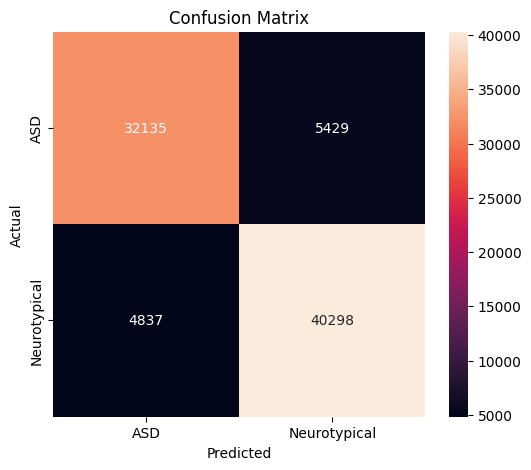

In [20]:

# =========================================
# CONFUSION MATRIX
# =========================================
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()



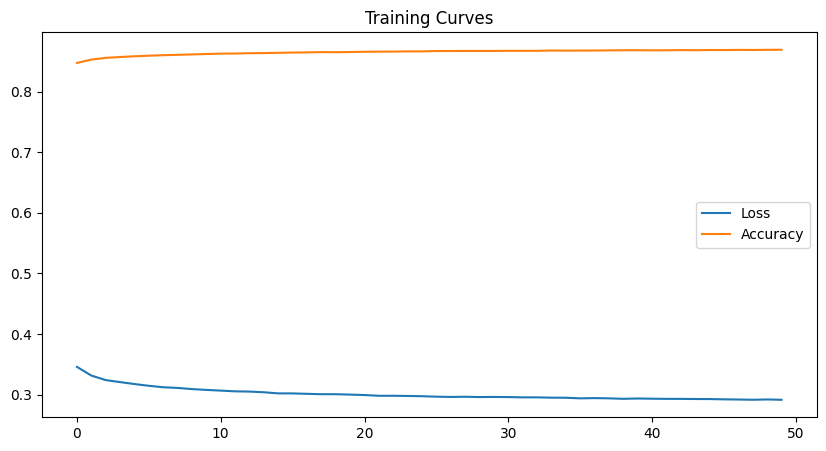

In [21]:

# =========================================
# TRAINING CURVES
# =========================================
plt.figure(figsize=(10, 5))

plt.plot(train_losses, label='Loss')
plt.plot(train_accuracies, label='Accuracy')

plt.legend()
plt.title('Training Curves')
plt.show()



In [25]:

# =========================================
# SAVE PREPROCESSING FILES
# =========================================
joblib.dump(scaler, 'scaler_new.pkl')
joblib.dump(label_encoder, 'label_encoder_new.pkl')

print("\nSaved:")
print("- best_autism_model.pth")
print("- scaler.pkl")
print("- label_encoder.pkl")




Saved:
- best_autism_model.pth
- scaler.pkl
- label_encoder.pkl


In [23]:

# =========================================
# SINGLE SAMPLE PREDICTION
# =========================================
def predict_sample(sample_features):

    sample = np.array(sample_features).reshape(1, -1)

    sample = scaler.transform(sample)

    sample_tensor = torch.tensor(
        sample,
        dtype=torch.float32
    ).to(device)

    model.eval()

    with torch.no_grad():

        outputs = model(sample_tensor)

        probabilities = torch.softmax(outputs, dim=1)

        predicted_class = torch.argmax(probabilities, dim=1)

        confidence = torch.max(probabilities).item()

    label = label_encoder.inverse_transform(
        [predicted_class.cpu().numpy()[0]]
    )[0]

    return label, confidence



In [24]:

# =========================================
# EXAMPLE PREDICTION
# =========================================
example_sample = X_test[0]

label, confidence = predict_sample(example_sample)

print("\nExample Prediction")
print("Prediction:", label)
print("Confidence:", round(confidence * 100, 2), "%")



Example Prediction
Prediction: ASD
Confidence: 82.95 %
